In [1]:
"""
SEC Filing Scraper
@Author: Nicholas Jung
"""

import requests
import pandas as pd

In [2]:
headers = {'User-Agent':
          "nicholasjung0503@gmail.com"}

target_tickers = ['LULU', 'UAA', 'DECK', 'PLNT', 'LTH', 'CELH',
                 'BRBR', 'GRMN']

In [3]:
print("getting the CIK master list..")
tickers_url = "https://www.sec.gov/files/company_tickers.json"
ciks_dict = requests.get(
    tickers_url,
    headers = headers
)
df_ciks = pd.DataFrame.from_dict(ciks_dict.json(), orient= "index")
df_ciks['cik_str']= df_ciks['cik_str'].astype(str).str.zfill(10)

getting the CIK master list..


### Pulling the XBRL tags

In [4]:
metrics_to_pull = {
    'Net_Revenue': ['Revenues', 'RevenueFromContractWithCustomerExcludingAssessedTax', 'SalesRevenueNet'],
    'Cost_of_Revenue': ['CostOfGoodsAndServicesSold', 'CostOfGoodsSold'],
    'Operating_Income': ['OperatingIncomeLoss']
}



### Little bit of logic
- since APIs are fragile, have to implement at try/except block that acts as a safety net. Otherwise, if a file is corrupted then the entire thing crashes, losing all your progress at the same time.


In [5]:
allCompanyData = []
for ticker in target_tickers:
    print(f"Processing {ticker}..")
    try:
        cik = df_ciks[df_ciks["ticker"] == ticker]['cik_str'].iloc[0]
        facts_url = f'https://data.sec.gov/api/xbrl/companyfacts/CIK{cik}.json'
        companyFacts = requests.get( facts_url,
                                     headers = headers
                                   )
        ## saves raw dictionary
        usgaapCompany = companyFacts.json()['facts']['us-gaap']

        for metric_name, xbrl_tags in metrics_to_pull.items():
            print(f"Hunting for: {metric_name}...")

            valid_tag = None

            for tag in xbrl_tags:
                if tag in usgaapCompany:
                    valid_tag = tag
                    break
            if valid_tag:
                print(f"Success : we found {valid_tag}")
                raw_data = usgaapCompany[valid_tag]['units']['USD']

                df_metric = pd.DataFrame(raw_data)
                df_quarterly = df_metric[df_metric['form'] == "10-Q"].copy() ##
                
                if 'segment' in df_quarterly.columns:
                    df_quarterly = df_quarterly[df_quarterly['segment'].isna()]
                    
                df_quarterly = df_quarterly.reset_index(drop = True)
                ## slicing two columns, making sure we rename
                df_quarterly = df_quarterly[['end', 'val']].rename(columns = {'end': 'Date', 'val': 'Value'})
                df_quarterly['Ticker'] = ticker
                df_quarterly['Metric'] = metric_name

                                                                       
                allCompanyData.append(df_quarterly)

            else:
                print(f" Warning: Could not find SEC tag for {metric_name}")
        
    except Exception as e:
        print(f"Error processing {ticker}: {e}")

print(allCompanyData)

Processing LULU..
Hunting for: Net_Revenue...
Success : we found RevenueFromContractWithCustomerExcludingAssessedTax
Hunting for: Cost_of_Revenue...
Success : we found CostOfGoodsAndServicesSold
Hunting for: Operating_Income...
Success : we found OperatingIncomeLoss
Processing UAA..
Hunting for: Net_Revenue...
Success : we found Revenues
Hunting for: Cost_of_Revenue...
Success : we found CostOfGoodsAndServicesSold
Hunting for: Operating_Income...
Success : we found OperatingIncomeLoss
Processing DECK..
Hunting for: Net_Revenue...
Success : we found RevenueFromContractWithCustomerExcludingAssessedTax
Hunting for: Cost_of_Revenue...
Success : we found CostOfGoodsAndServicesSold
Hunting for: Operating_Income...
Success : we found OperatingIncomeLoss
Processing PLNT..
Hunting for: Net_Revenue...
Success : we found RevenueFromContractWithCustomerExcludingAssessedTax
Hunting for: Cost_of_Revenue...
Hunting for: Operating_Income...
Success : we found OperatingIncomeLoss
Processing LTH..
Hunti

### Submitting all into one, clean dataset.

In [6]:
pd.concat(allCompanyData)

,Date,Value,Ticker,Metric
0,2018-10-28,2120861000,LULU,Net_Revenue
1,2018-10-28,747655000,LULU,Net_Revenue
2,2019-05-05,782315000,LULU,Net_Revenue
3,2019-08-04,1665667000,LULU,Net_Revenue
4,2019-08-04,883352000,LULU,Net_Revenue
...,...,...,...,...
157,2025-06-28,805119000,GRMN,Operating_Income
158,2025-06-28,472295000,GRMN,Operating_Income
159,2025-09-27,1261922000,GRMN,Operating_Income
160,2025-09-27,456803000,GRMN,Operating_Income


In [7]:
df_final = pd.concat(allCompanyData)
df_final = df_final.reset_index()
# df_test_revenue = df_final[df_final['Metric'] == 'Net_Revenue']

### Changing the Date format, maybe will help with pivoting

In [8]:
# df_final["Date"] = pd.to_datetime(df_final['Date'], format = 'mixed')
# df_final['clean_date'] = df_final["Date"].dt.strftime('%b %d, %Y')

In [9]:
## Testing df_revenue metric since it shows NA once pivoted
print(df_final["Metric"].unique())
print(df_final["Ticker"].unique())

['Net_Revenue' 'Cost_of_Revenue' 'Operating_Income']
['LULU' 'UAA' 'DECK' 'PLNT' 'LTH' 'CELH' 'BRBR' 'GRMN']


### Explanation for why there are no Cost_of_Revenue and Net_Revenue prior to 2017
- Accounting standard called **ASC 606** was in effect, and changed how companies were required to recognize and report revenue.

#### Additionally, pivoted the tables below to make metrics into columns

In [10]:
df_pivot = df_final.pivot_table(index = ["Date", "Ticker"], 
                                     columns = ["Metric"], 
                                     values = "Value",
                                    aggfunc = "sum").reset_index()

#### To ensure all tickers were processed.

In [11]:
print(df_pivot['Ticker'].unique())

['GRMN' 'DECK' 'UAA' 'LULU' 'PLNT' 'CELH' 'BRBR' 'LTH']


#### Realized that category of gyms dont have a Cost_of_Revenue here, and deleted all of the data.

In [12]:
print(df_pivot[df_pivot['Ticker'] == 'PLNT'])

Metric        Date Ticker  Cost_of_Revenue   Net_Revenue  Operating_Income
68      2014-09-30   PLNT              NaN           NaN        56153000.0
73      2015-03-31   PLNT              NaN           NaN        14302000.0
78      2015-06-30   PLNT              NaN           NaN        51640000.0
84      2015-09-30   PLNT              NaN           NaN       107298000.0
90      2016-03-31   PLNT              NaN           NaN        51220000.0
96      2016-06-30   PLNT              NaN           NaN       162542000.0
102     2016-09-30   PLNT              NaN           NaN       211492000.0
107     2017-03-31   PLNT              NaN           NaN        66110000.0
113     2017-06-30   PLNT              NaN           NaN       219110000.0
120     2017-09-30   PLNT              NaN  3.934100e+08       278426000.0
126     2018-03-31   PLNT              NaN  1.213330e+08        77836000.0
132     2018-06-30   PLNT              NaN  4.024320e+08       273080000.0
138     2018-09-30   PLNT

### Why Celsius (CELH) can not be called
- In 2015, **SEC charged Celsius Holding, Inc for internal accounting failures**. They had adequate internal accounting and disclosure, as well as an overstatement of net income for one quarter (400% over estimate). They had inadequate disclosure from 2019 to 2023.

#### Below attached is the representation of CELH data-table
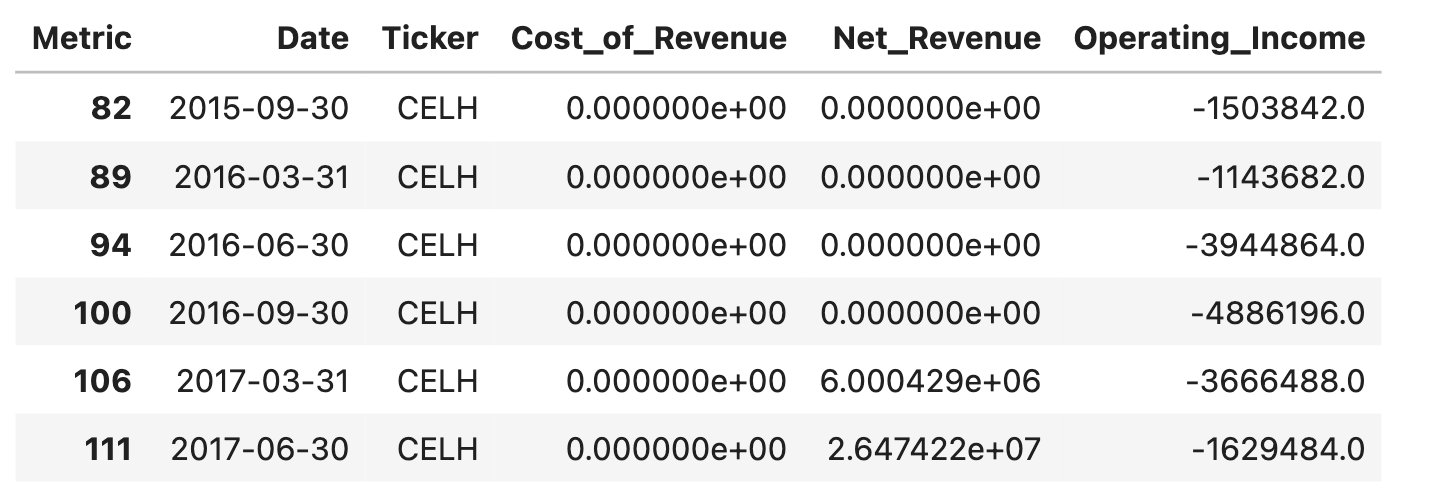


- And even when the company started reporting their cost_of_revenue, net_revenue was failed to be accounted for.
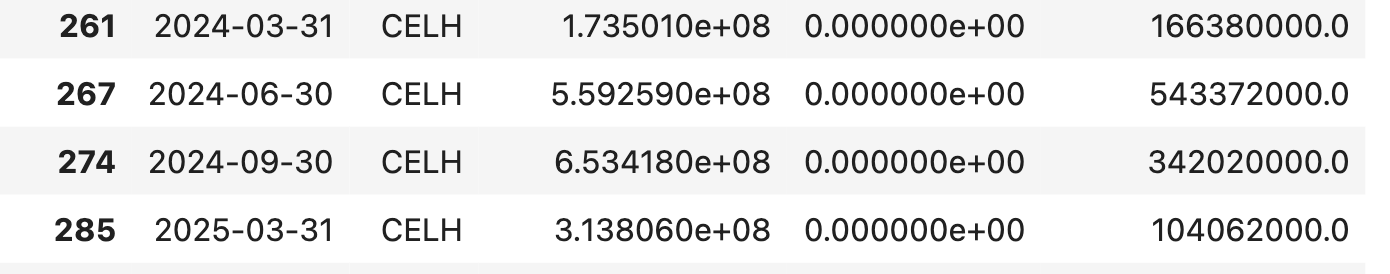


#### Changing to fill all NA values to 0, and got rid of the values that have 0s afterwards

In [13]:
df_pivot = df_pivot.fillna(0)
df_clean = df_pivot.copy()

df_clean = df_clean[(df_clean["Net_Revenue"] != 0.0)]

df_clean['Ticker'].unique()

array(['CELH', 'DECK', 'UAA', 'PLNT', 'LULU', 'BRBR', 'GRMN', 'LTH'],
      dtype=object)

#### Ensure the data is accurate, and categorize them based on their brand

In [14]:
df_clean = df_clean.sort_values(by= ["Ticker", "Date"])

## Make sure that all tickers are present
print(f"These are the unique columns made {df_clean['Ticker'].unique()} \n")

## this is to show the shape 
print(f"This is the messy dataframe {df_pivot.shape} \nThis is the clean dataset {df_clean.shape}. \n")

## Messy DF including the 0 for net revenue
print(f"This is the Messy data table: \n{df_pivot.head(5)}\n")

## Cleaned DF
print(f"This is the cleaned data table: \n{df_clean.head(5)}")

These are the unique columns made ['BRBR' 'CELH' 'DECK' 'GRMN' 'LTH' 'LULU' 'PLNT' 'UAA'] 

This is the messy dataframe (312, 5) 
This is the clean dataset (184, 5). 

This is the Messy data table: 
Metric        Date Ticker  Cost_of_Revenue  Net_Revenue  Operating_Income
0       2008-09-27   GRMN     1.807664e+09          0.0       839961000.0
1       2009-03-28   GRMN     2.407040e+08          0.0        57959000.0
2       2009-06-27   GRMN     8.756840e+08          0.0       456263000.0
3       2009-06-30   DECK     0.000000e+00          0.0        25776000.0
4       2009-06-30    UAA     0.000000e+00          0.0        14658000.0

This is the cleaned data table: 
Metric        Date Ticker  Cost_of_Revenue   Net_Revenue  Operating_Income
141     2018-12-31   BRBR              0.0  1.858000e+08        32900000.0
144     2019-03-31   BRBR              0.0  6.188000e+08       114500000.0
150     2019-06-30   BRBR              0.0  8.775000e+08       179300000.0
162     2019-12-31   BR

### This groups by Ticker to ensure values will be calculated in chronological order.


## Initialized new columns:
- **Gross Profit** = $NetRevenue-CostofRevenue$
- **Gross Margin PCT** = $GrossProfit/Revenue$
- **Operating Margin PCT** = $OperatingIncome/Revenue$
- **Year over Year growth**


In [15]:
df_clean["Gross_Profit"] = df_clean["Net_Revenue"] - df_clean["Cost_of_Revenue"]
df_clean["Gross_Margin_Pct"] = df_clean["Gross_Profit"]/df_clean["Net_Revenue"] * 100
df_clean["Operating_Margin_Pct"] = df_clean["Operating_Income"] / df_clean["Net_Revenue"] * 100
df_clean["yoy_growth"] = df_clean.groupby('Ticker')["Net_Revenue"].pct_change(periods=4) * 100

In [16]:
df_clean["Ticker"].unique()

array(['BRBR', 'CELH', 'DECK', 'GRMN', 'LTH', 'LULU', 'PLNT', 'UAA'],
      dtype=object)

In [17]:
df_clean[df_clean['Cost_of_Revenue'] == 0]

Metric,Date,Ticker,Cost_of_Revenue,Net_Revenue,Operating_Income,Gross_Profit,Gross_Margin_Pct,Operating_Margin_Pct,yoy_growth
141,2018-12-31,BRBR,0.0,1.858000e+08,32900000.0,1.858000e+08,100.0,17.707212,NaN
144,2019-03-31,BRBR,0.0,6.188000e+08,114500000.0,6.188000e+08,100.0,18.503555,NaN
150,2019-06-30,BRBR,0.0,8.775000e+08,179300000.0,8.775000e+08,100.0,20.433048,NaN
162,2019-12-31,BRBR,0.0,4.880000e+08,98600000.0,4.880000e+08,100.0,20.204918,NaN
165,2020-03-31,BRBR,0.0,1.518000e+09,239000000.0,1.518000e+09,100.0,15.744401,717.007535
...,...,...,...,...,...,...,...,...,...
277,2024-09-30,PLNT,0.0,2.266900e+09,631406000.0,2.266900e+09,100.0,27.853280,42.545073
287,2025-03-31,PLNT,0.0,5.533240e+08,158404000.0,5.533240e+08,100.0,28.627712,-73.992824
294,2025-06-30,PLNT,0.0,9.584200e+08,284006000.0,9.584200e+08,100.0,29.632729,93.216594
301,2025-09-30,PLNT,0.0,1.278231e+09,395740000.0,1.278231e+09,100.0,30.959975,-24.801006


### Grouping by a category, and then grouping by ticker and 

In [18]:
import plotly.express as px 
import numpy as np

category_map = {
    'LULU': 'Apparel',
    'UAA': 'Apparel',
    'NKE': 'Apparel',
    'DECK': 'Apparel',

    'PLNT': 'Gyms',
    'LTH': 'Gyms',

    'PTON': 'Gym Equipment',

    'CELH': 'Consumables & Supplements',
    'BRBR': 'Consumables & Supplements',
    'GPN': 'Consumables & Supplements',

    'GRMN': "Wearables"
}

df_clean["Category"] = df_clean['Ticker'].map(category_map)

df_grouped = df_clean.copy()
df_grouped

Metric,Date,Ticker,Cost_of_Revenue,Net_Revenue,Operating_Income,Gross_Profit,Gross_Margin_Pct,Operating_Margin_Pct,yoy_growth,Category
141,2018-12-31,BRBR,0.000000e+00,1.858000e+08,32900000.0,1.858000e+08,100.000000,17.707212,NaN,Consumables & Supplements
144,2019-03-31,BRBR,0.000000e+00,6.188000e+08,114500000.0,6.188000e+08,100.000000,18.503555,NaN,Consumables & Supplements
150,2019-06-30,BRBR,0.000000e+00,8.775000e+08,179300000.0,8.775000e+08,100.000000,20.433048,NaN,Consumables & Supplements
162,2019-12-31,BRBR,0.000000e+00,4.880000e+08,98600000.0,4.880000e+08,100.000000,20.204918,NaN,Consumables & Supplements
165,2020-03-31,BRBR,0.000000e+00,1.518000e+09,239000000.0,1.518000e+09,100.000000,15.744401,717.007535,Consumables & Supplements
...,...,...,...,...,...,...,...,...,...,...
278,2024-09-30,UAA,4.053544e+09,7.963422e+09,92864000.0,3.909878e+09,49.097963,1.166132,202.334531,Apparel
282,2024-12-31,UAA,5.591298e+09,1.076953e+10,-199260000.0,5.178234e+09,48.082256,-1.850220,20.995849,Apparel
295,2025-06-30,UAA,5.875720e+08,1.134068e+09,3323000.0,5.464960e+08,48.188997,0.293016,-90.316742,Apparel
302,2025-09-30,UAA,1.993164e+09,3.800828e+09,37415000.0,1.807664e+09,47.559742,0.984391,60.553366,Apparel


### Can technically automate this by parsing through each row, and seeing when the lowest value is a 0 for the company, and make that the new date that it can graph

However, I just manually checked

In [19]:

df_clean = df_clean[df_clean['Date'] >= '2020-5-31']
group_metrics = ['Gross_Margin_Pct', 'Operating_Margin_Pct', 'yoy_growth']

df_grouped = df_clean.copy()
df_grouped = df_clean.groupby(['Date', 'Category'])[group_metrics].mean().reset_index()
df_grouped["Category"].unique()

# Apply a 2-quarter rolling average to smooth the noise
df_grouped['smoothed_yoy'] = df_grouped.groupby('Category')['yoy_growth'].transform(lambda x: x.rolling(window=10, min_periods=3).mean())

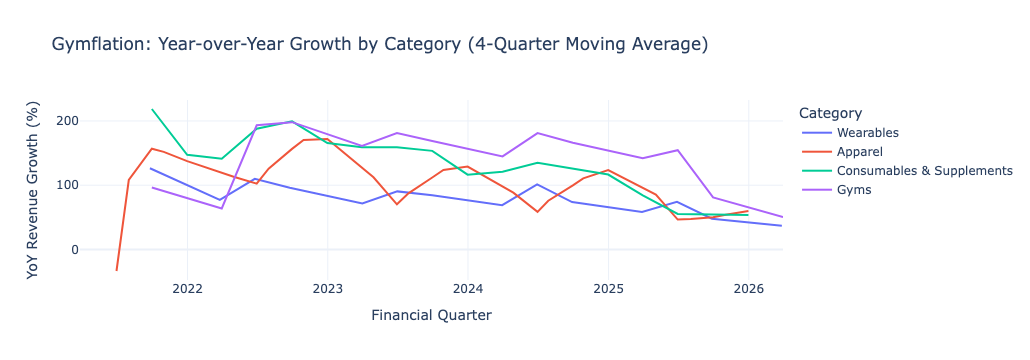

In [55]:
import plotly.express as px
import hvplot.pandas

fig = px.line(
    df_grouped,
    x = "Date",
    y = "smoothed_yoy",
    color = 'Category',
    title= 'Gymflation: Year-over-Year Growth by Category (4-Quarter Moving Average)',
    template = 'plotly_white'
)
fig.update_traces = line = dict(width =3)
fig.update_layout(
    xaxis_title = "Financial Quarter",
    yaxis_title = "YoY Revenue Growth (%)"
)
fig.show()

### Reports
- Wearables saw in 2021 a 266% growth
- Consumables were 207% growth
- Gyms were 147% growth
- And apparels initially saw an 85% increase


In [53]:
df_grouped["Date"] = pd.to_datetime(df_grouped['Date'])
df_grouped["Year"] = df_grouped["Date"].dt.year
df_yearly = df_grouped.groupby(['Year', 'Category'])["yoy_growth"].mean().reset_index()
df_yearly_table = df_yearly.pivot( columns = "Category", values = "yoy_growth", index = "Year")
df_yearly_table = df_yearly_table.round(2)

In [57]:
df_yearly_table[df_yearly_table.index >= 2025].mean()

Category
Apparel                     -10.380
Consumables & Supplements    -3.230
Gyms                        -43.295
Wearables                   -43.455
dtype: float64

#### From 2021 - 2025, the mean average each category saw in YoY:
- **Apparel**: 107.73%
- **Consumables & Supplements**: 123.13%
- **Gyms**: 148.40%
- **Wearables**: 86.06%

#### From 2025-Now, the mean average each category saw in YoY:
- **Apparel**: -10.38%
- **Consumables & Supplements**: -3.23%
- **Gyms**: -43.30%
- **Wearables**: 43.46%